In [7]:
import json
import pandas as pd

In [31]:
df = pd.read_sql(
    """
    SELECT
      timestamp_utc AS timestamp,
      engine_max_rpm,
      current_engine_rpm,
      acceleration_x, acceleration_y, acceleration_z,
      velocity_x, velocity_y, velocity_z,
      yaw, pitch, roll,
      position_x, position_y, position_z,
      speed, power, torque, steer,
      best_lap, current_lap, lap_number, race_position
    FROM telemetry_samples
    WHERE lap_number = 0
    AND distance_traveled != 0
    ORDER BY id
    LIMIT 300
    """,
    "sqlite:///track1.db",
)

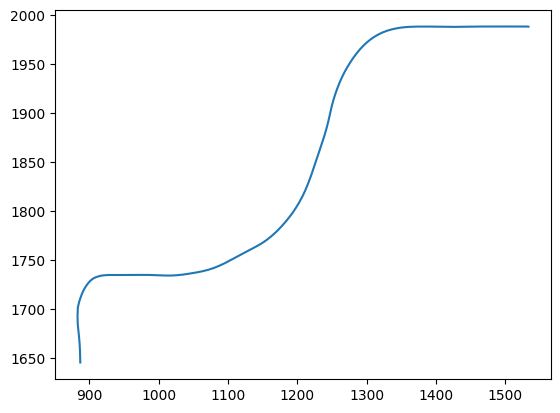

In [32]:
import matplotlib.pyplot as plt
plt.plot(df['position_x'], df['position_z'])

In [33]:
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True).astype("int64") // 10**6
df["timestamp"] = df["timestamp"] - df["timestamp"].min()
# new_df = df.iloc[::18, :]

In [34]:
records = df.to_dict(orient="records")
with open("segment_data.json", "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print(f"{len(df)} Einträge geschrieben nach segment_data.json")

300 Einträge geschrieben nach segment_data.json
